# FDEPH pHash-256 — Attack Efficiency Analysis

**Author:** Avijit Roy  
**Project:** FDEPH — Security Evaluation of Perceptual Image Hashing  
**PI:** Prof. Shweta Jain  
**Date:** April 2026  

This notebook performs the full analysis of the pHash-256 evasion attack results, including:
- Summary statistics (median, mean, percentiles, IQR) across all four thresholds
- Distribution analysis: steps, L∞, SSIM, dist_raw — histograms + CDFs
- Quantization structure analysis (even-integer bit flip pattern)
- T=0.30 failure analysis
- Cross-algorithm comparison at T=0.10 (pHash-64 vs pHash-256 vs PDQ vs NeuralHash)
- All figures saved to `fdeph_eval/analysis/figures/`
- All tables saved to `fdeph_eval/analysis/tables/`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import scipy.stats as stats
from pathlib import Path
from collections import Counter

# ── Paths ──────────────────────────────────────────────────────────────────
# Resolve repository root robustly (works whether notebook is opened from repo root
# or from inside fdeph_eval/analysis).
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = next((p for p in candidate_roots if (p / 'logs').exists()), Path.cwd().parent)

LOGS_DIR = REPO_ROOT / 'logs'
FIGURES_DIR = REPO_ROOT / 'fdeph_eval' / 'analysis' / 'figures'
TABLES_DIR = REPO_ROOT / 'fdeph_eval' / 'analysis' / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# ── Palette ────────────────────────────────────────────────────────────────
COLORS = {
    'T008': '#2196F3',   # blue
    'T010': '#4CAF50',   # green
    'T012': '#FF9800',   # orange
    'T030': '#F44336',   # red
    'phash64':   '#9C27B0',  # purple
    'phash256':  '#2196F3',  # blue
    'pdq':       '#FF5722',  # deep orange
    'neuralhash':'#607D8B',  # blue-grey
}

THRESHOLDS = [0.08, 0.10, 0.12, 0.30]
THRESH_LABELS = ['T=0.08', 'T=0.10', 'T=0.12', 'T=0.30']
THRESH_KEYS   = ['T008', 'T010', 'T012', 'T030']

print('Setup complete.')
print(f'Repo root → {REPO_ROOT}')
print(f'Figures   → {FIGURES_DIR}')
print(f'Tables    → {TABLES_DIR}')

Setup complete.
Repo root → /home/exouser/ar-sec-eval
Figures   → /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures
Tables    → /home/exouser/ar-sec-eval/fdeph_eval/analysis/tables


## 1. Load and Validate Data

In [2]:
candidate_logs_dirs = [
    LOGS_DIR,
    Path.cwd() / 'logs',
    Path.cwd().parent / 'logs',
    Path.cwd().parent.parent / 'logs',
]
logs_dir = next((d for d in candidate_logs_dirs if d.exists()), LOGS_DIR)
print(f'Using logs dir: {logs_dir}')

dfs = {}
for t in THRESHOLDS:
    primary_name = f'attack_steps_phash256_evasion_mt500_T{t:.2f}.csv'
    alt_name = f'attack_steps_phash256_evasion_mt500_T{t:.2f}'.replace('.', '_') + '.csv'

    fname = logs_dir / primary_name
    if not fname.exists():
        fname_alt = logs_dir / alt_name
        if fname_alt.exists():
            fname = fname_alt

    if not fname.exists():
        raise FileNotFoundError(
            f'Could not find log for T={t:.2f}. Tried: {primary_name} and {alt_name} in {logs_dir}'
        )

    df = pd.read_csv(fname)
    dfs[t] = df
    n_total = len(df)
    n_success = int(df['success'].sum())
    print(
        f'T={t:.2f}: {n_total} rows | {n_success} successes '
        f'({n_success / n_total * 100:.1f}%) | columns: {list(df.columns)}'
    )

# Separate success / failure subsets
success = {t: dfs[t][dfs[t]['success'] == 1].copy() for t in THRESHOLDS}
failure = {t: dfs[t][dfs[t]['success'] == 0].copy() for t in THRESHOLDS}

Using logs dir: /home/exouser/ar-sec-eval/logs
T=0.08: 500 rows | 500 successes (100.0%) | columns: ['image_id', 'threshold', 'success', 'steps', 'dist_norm', 'dist_raw', 'l2', 'l_inf', 'ssim', 'time_ms', 'orig_hash_hex', 'final_hash_hex']
T=0.10: 500 rows | 500 successes (100.0%) | columns: ['image_id', 'threshold', 'success', 'steps', 'dist_norm', 'dist_raw', 'l2', 'l_inf', 'ssim', 'time_ms', 'orig_hash_hex', 'final_hash_hex']
T=0.12: 500 rows | 500 successes (100.0%) | columns: ['image_id', 'threshold', 'success', 'steps', 'dist_norm', 'dist_raw', 'l2', 'l_inf', 'ssim', 'time_ms', 'orig_hash_hex', 'final_hash_hex']
T=0.30: 500 rows | 422 successes (84.4%) | columns: ['image_id', 'threshold', 'success', 'steps', 'dist_norm', 'dist_raw', 'l2', 'l_inf', 'ssim', 'time_ms', 'orig_hash_hex', 'final_hash_hex']


## 2. Full Summary Statistics Table

In [3]:
def full_stats(series, name=''):
    """Return a dict of summary stats for a numeric series."""
    s = series.dropna()
    return {
        'n': len(s),
        'min': s.min(),
        'p05': s.quantile(0.05),
        'p25 (Q1)': s.quantile(0.25),
        'median (p50)': s.median(),
        'mean': s.mean(),
        'p75 (Q3)': s.quantile(0.75),
        'p95': s.quantile(0.95),
        'p99': s.quantile(0.99),
        'max': s.max(),
        'std': s.std(),
        'IQR': s.quantile(0.75) - s.quantile(0.25),
        'skewness': float(stats.skew(s)),
        'kurtosis': float(stats.kurtosis(s)),
    }

metrics = ['steps', 'l_inf', 'ssim', 'dist_raw', 'l2', 'time_ms']
rows = []
for t in THRESHOLDS:
    s = success[t]
    for m in metrics:
        st = full_stats(s[m])
        st['threshold'] = t
        st['metric'] = m
        st['n_success'] = len(s)
        st['n_total'] = len(dfs[t])
        rows.append(st)

stats_df = pd.DataFrame(rows)
stats_df = stats_df[['threshold', 'metric', 'n_success', 'n_total',
                      'min', 'p05', 'p25 (Q1)', 'median (p50)', 'mean',
                      'p75 (Q3)', 'p95', 'p99', 'max', 'std', 'IQR',
                      'skewness', 'kurtosis']]

out_path = TABLES_DIR / 'phash256_full_summary_stats.csv'
stats_df.to_csv(out_path, index=False, float_format='%.6f')
print(f'Saved: {out_path}')

# Pretty print steps summary
print('\n── Steps summary (successes only) ──')
steps_pivot = stats_df[stats_df['metric']=='steps'][[
    'threshold','n_success','n_total','median (p50)','mean','p25 (Q1)',
    'p75 (Q3)','p95','max','std','skewness'
]].set_index('threshold')
print(steps_pivot.round(2).to_string())

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/tables/phash256_full_summary_stats.csv

── Steps summary (successes only) ──
           n_success  n_total  median (p50)    mean  p25 (Q1)  p75 (Q3)      p95     max     std  skewness
threshold                                                                                                 
0.08             500      500          28.0   35.03     19.00      40.0    76.00   451.0   34.00      6.72
0.10             500      500          35.0   46.29     24.00      52.0   103.20   609.0   46.70      6.01
0.12             500      500          49.0   67.62     32.00      75.0   159.35  1301.0   83.44      8.10
0.30             422      500         263.0  378.08    136.25     468.5  1270.50  1972.0  366.38      1.99


## 3. Steps Distribution — Histograms + KDE across Thresholds

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_steps_histogram_kde.png


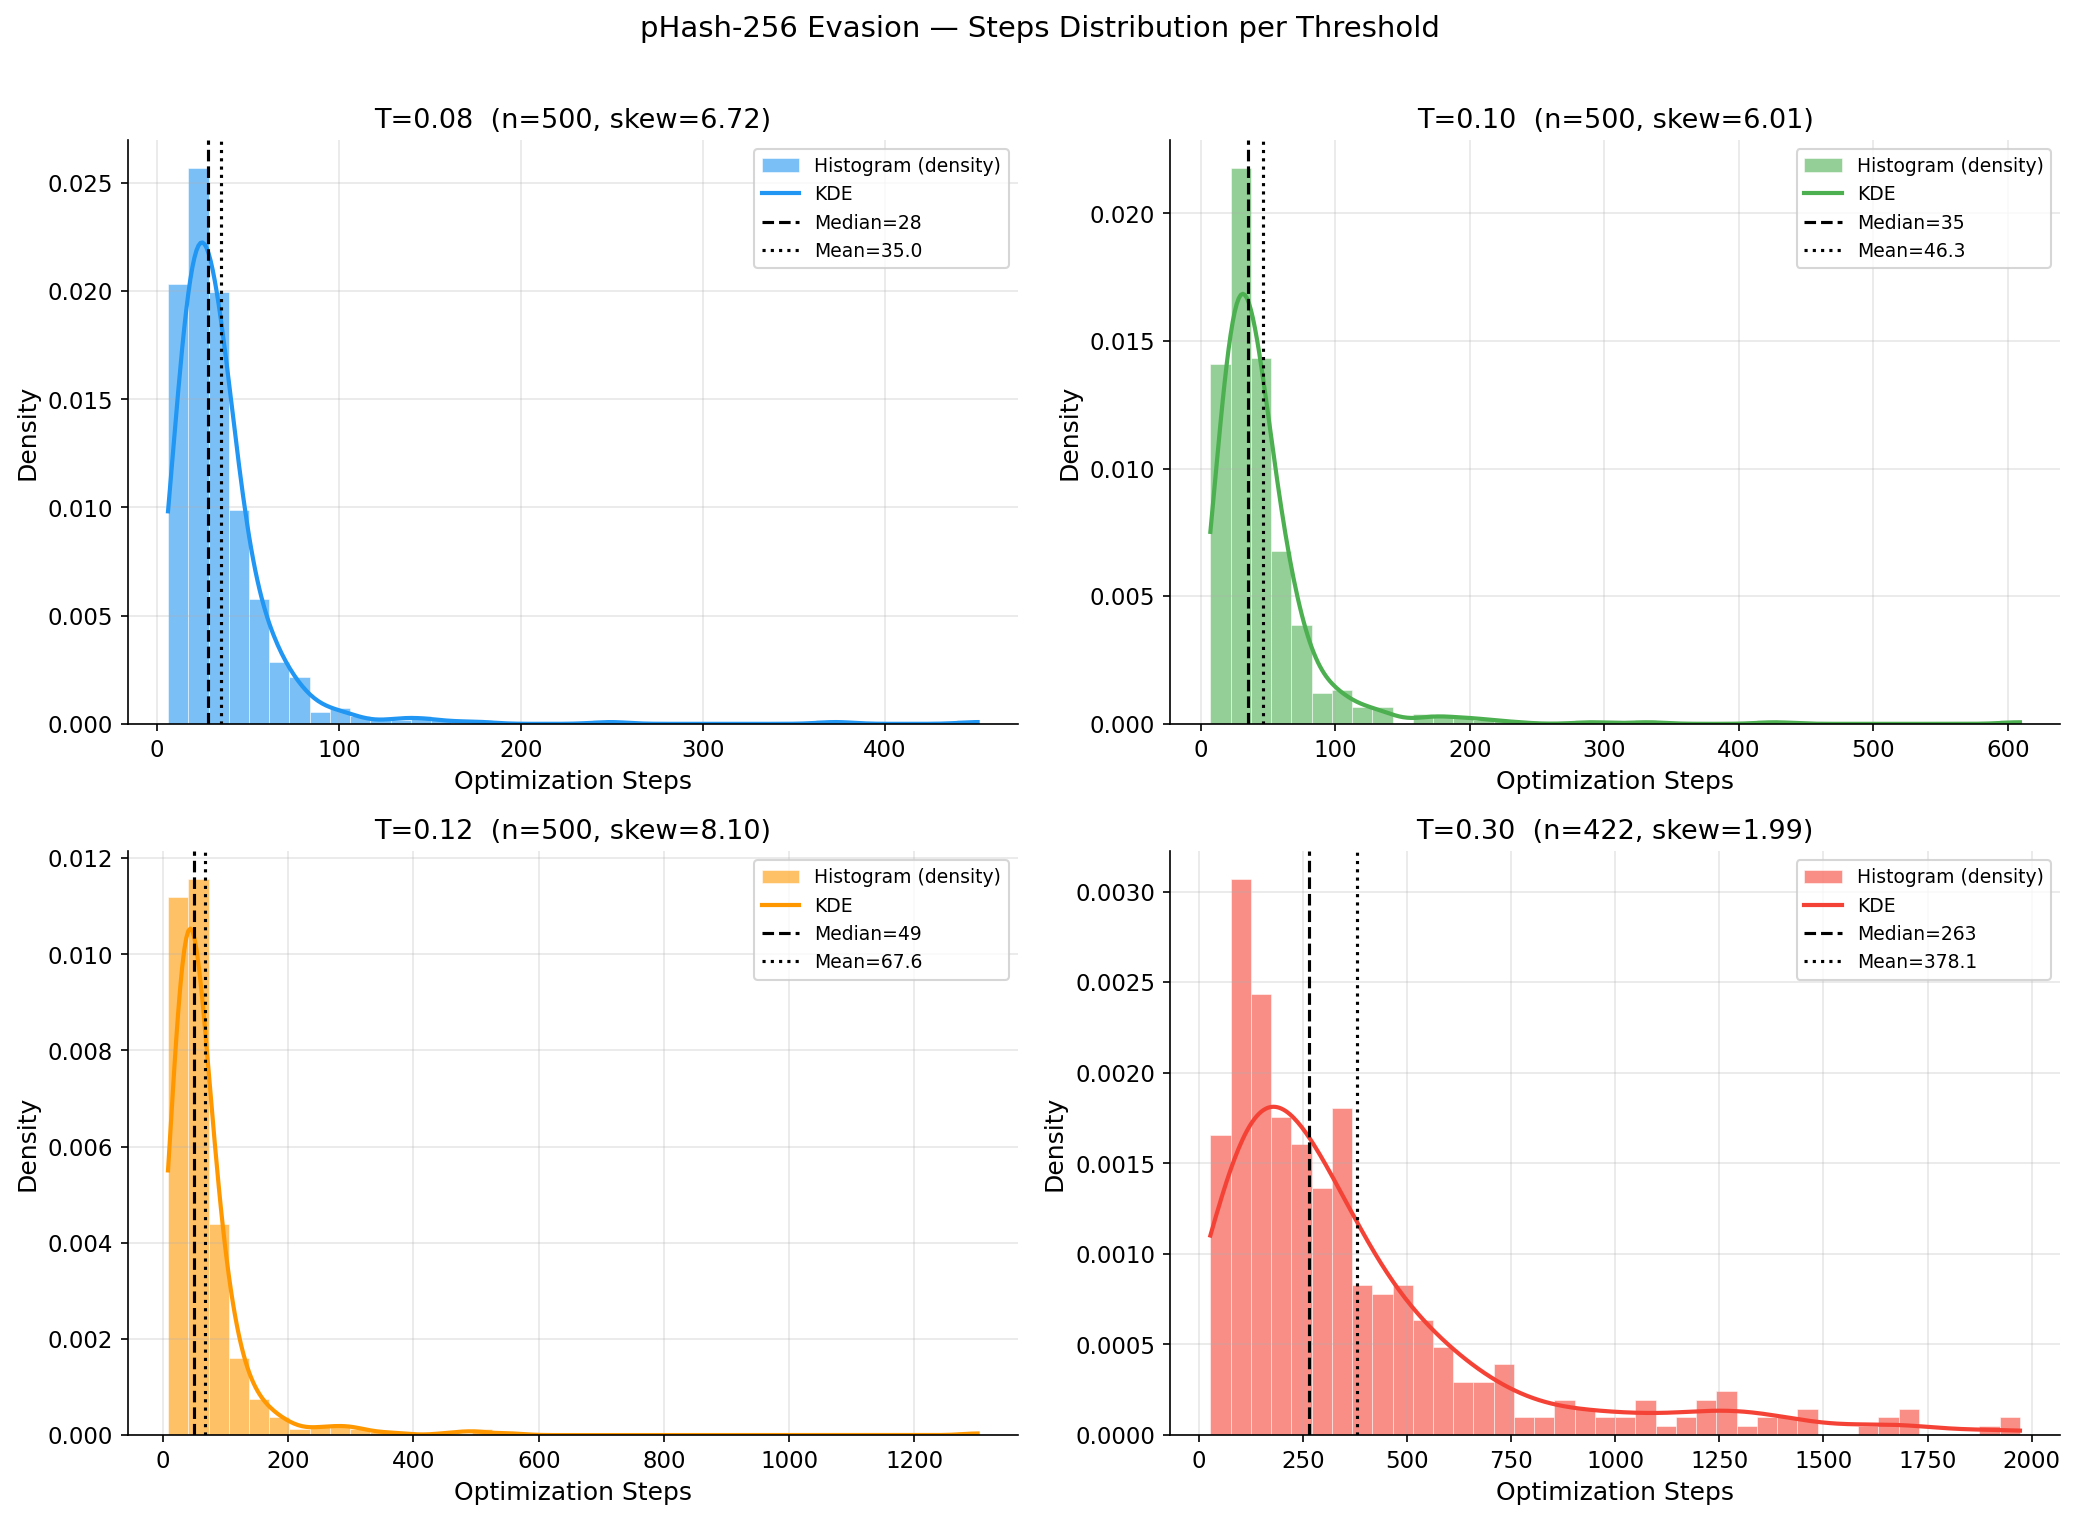

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (t, key, label) in enumerate(zip(THRESHOLDS, THRESH_KEYS, THRESH_LABELS)):
    ax = axes[i]
    s = success[t]['steps']
    color = COLORS[key]

    # Histogram
    ax.hist(s, bins=40, color=color, alpha=0.6, edgecolor='white', linewidth=0.4,
            density=True, label='Histogram (density)')

    # KDE
    kde = stats.gaussian_kde(s, bw_method='scott')
    xgrid = np.linspace(s.min(), s.max(), 400)
    ax.plot(xgrid, kde(xgrid), color=color, linewidth=2.0, label='KDE')

    # Vertical lines
    med = s.median()
    mn  = s.mean()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.5, label=f'Median={med:.0f}')
    ax.axvline(mn,  color='black', linestyle=':',  linewidth=1.5, label=f'Mean={mn:.1f}')

    ax.set_title(f'{label}  (n={len(s)}, skew={stats.skew(s):.2f})')
    ax.set_xlabel('Optimization Steps')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

fig.suptitle('pHash-256 Evasion — Steps Distribution per Threshold', fontsize=14, y=1.01)
plt.tight_layout()
out = FIGURES_DIR / 'phash256_steps_histogram_kde.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 4. Steps Distribution — Overlaid CDFs across Thresholds

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_steps_cdf.png


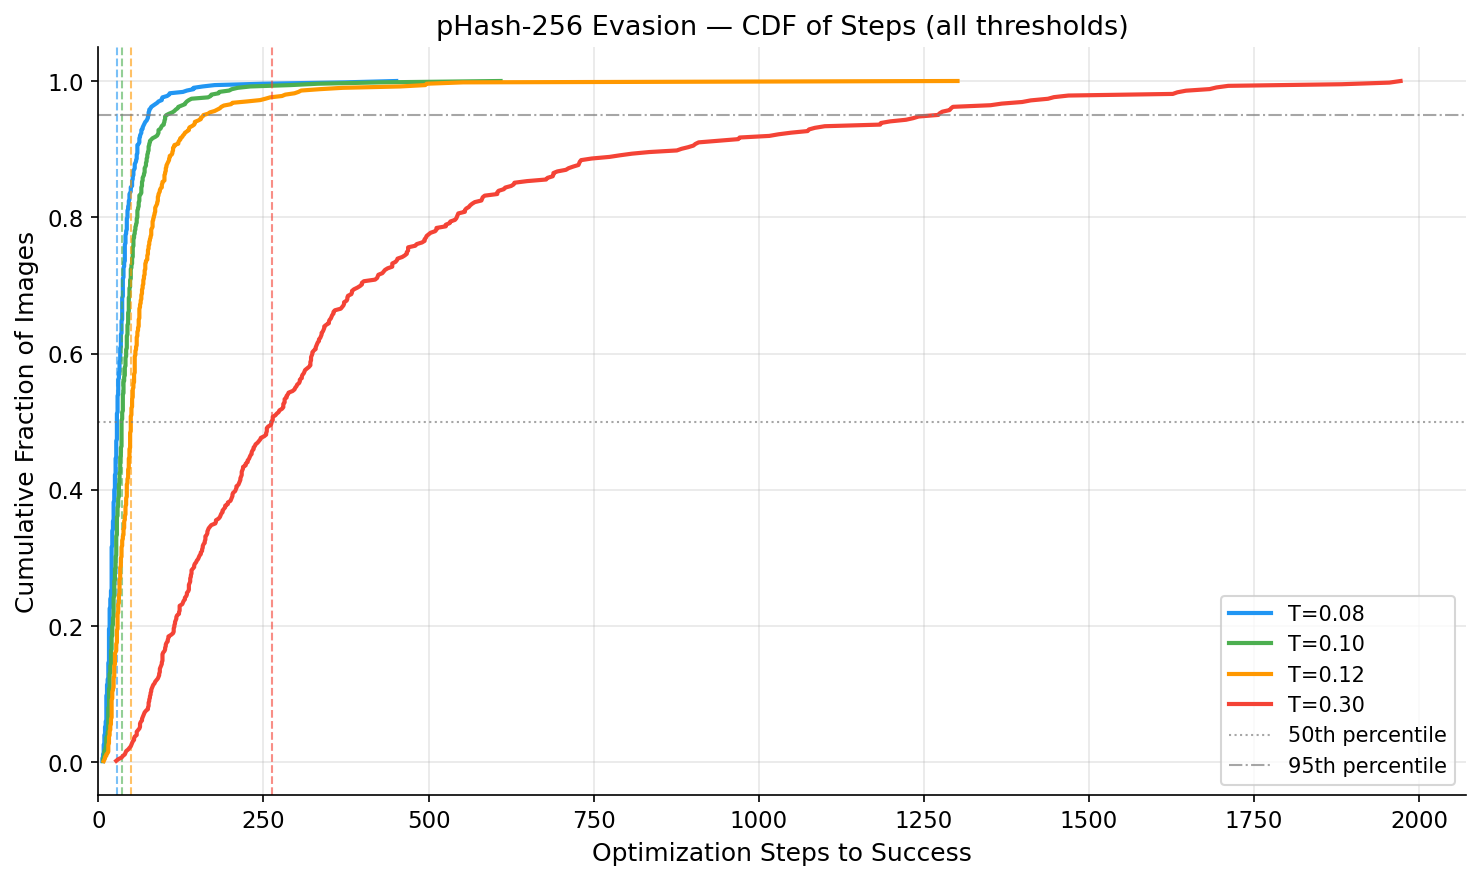

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for t, key, label in zip(THRESHOLDS, THRESH_KEYS, THRESH_LABELS):
    s = np.sort(success[t]['steps'].values)
    cdf = np.arange(1, len(s)+1) / len(s)
    ax.plot(s, cdf, color=COLORS[key], linewidth=2.0, label=label)
    med = np.median(s)
    ax.axvline(med, color=COLORS[key], linestyle='--', linewidth=1.0, alpha=0.6)

ax.axhline(0.50, color='grey', linestyle=':', linewidth=1.0, alpha=0.7, label='50th percentile')
ax.axhline(0.95, color='grey', linestyle='-.', linewidth=1.0, alpha=0.7, label='95th percentile')
ax.set_xlabel('Optimization Steps to Success')
ax.set_ylabel('Cumulative Fraction of Images')
ax.set_title('pHash-256 Evasion — CDF of Steps (all thresholds)')
ax.legend()
ax.set_xlim(left=0)

plt.tight_layout()
out = FIGURES_DIR / 'phash256_steps_cdf.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 5. Success Rate vs Steps (Fraction Solved by Step N)

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_success_rate_vs_steps.png


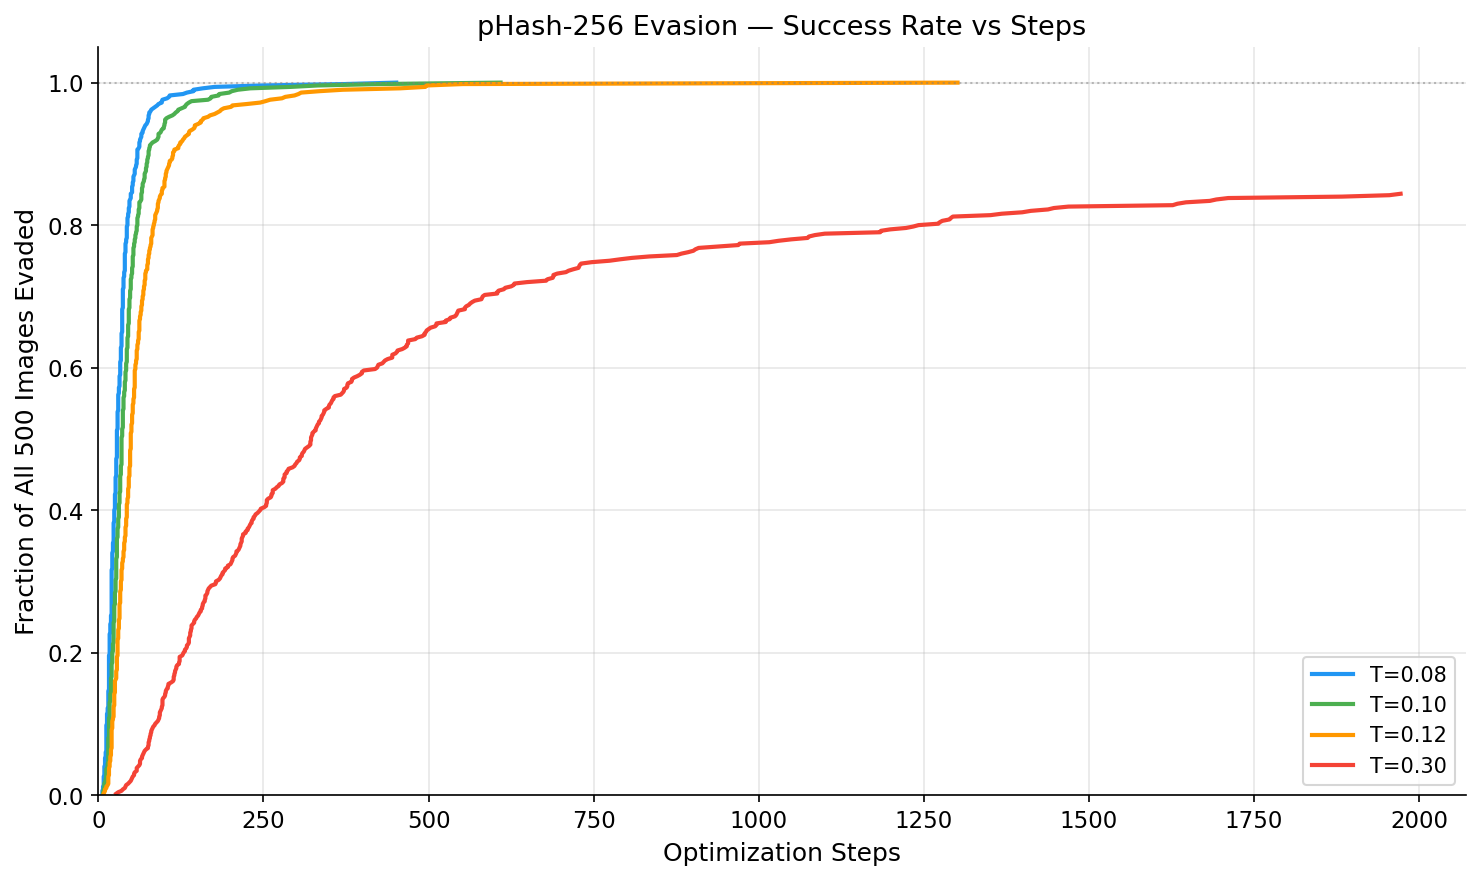

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for t, key, label in zip(THRESHOLDS, THRESH_KEYS, THRESH_LABELS):
    df = dfs[t]
    n_total = len(df)
    s_steps = np.sort(success[t]['steps'].values)
    # cumulative fraction of TOTAL images solved by step N
    cdf_of_total = np.arange(1, len(s_steps)+1) / n_total
    ax.plot(s_steps, cdf_of_total, color=COLORS[key], linewidth=2.0, label=label)

ax.axhline(1.0, color='grey', linestyle=':', linewidth=1.0, alpha=0.5)
ax.set_xlabel('Optimization Steps')
ax.set_ylabel('Fraction of All 500 Images Evaded')
ax.set_title('pHash-256 Evasion — Success Rate vs Steps')
ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
out = FIGURES_DIR / 'phash256_success_rate_vs_steps.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 6. Threshold Sweep Bar Chart — Median Steps, L∞, SSIM

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_threshold_sweep_bars.png


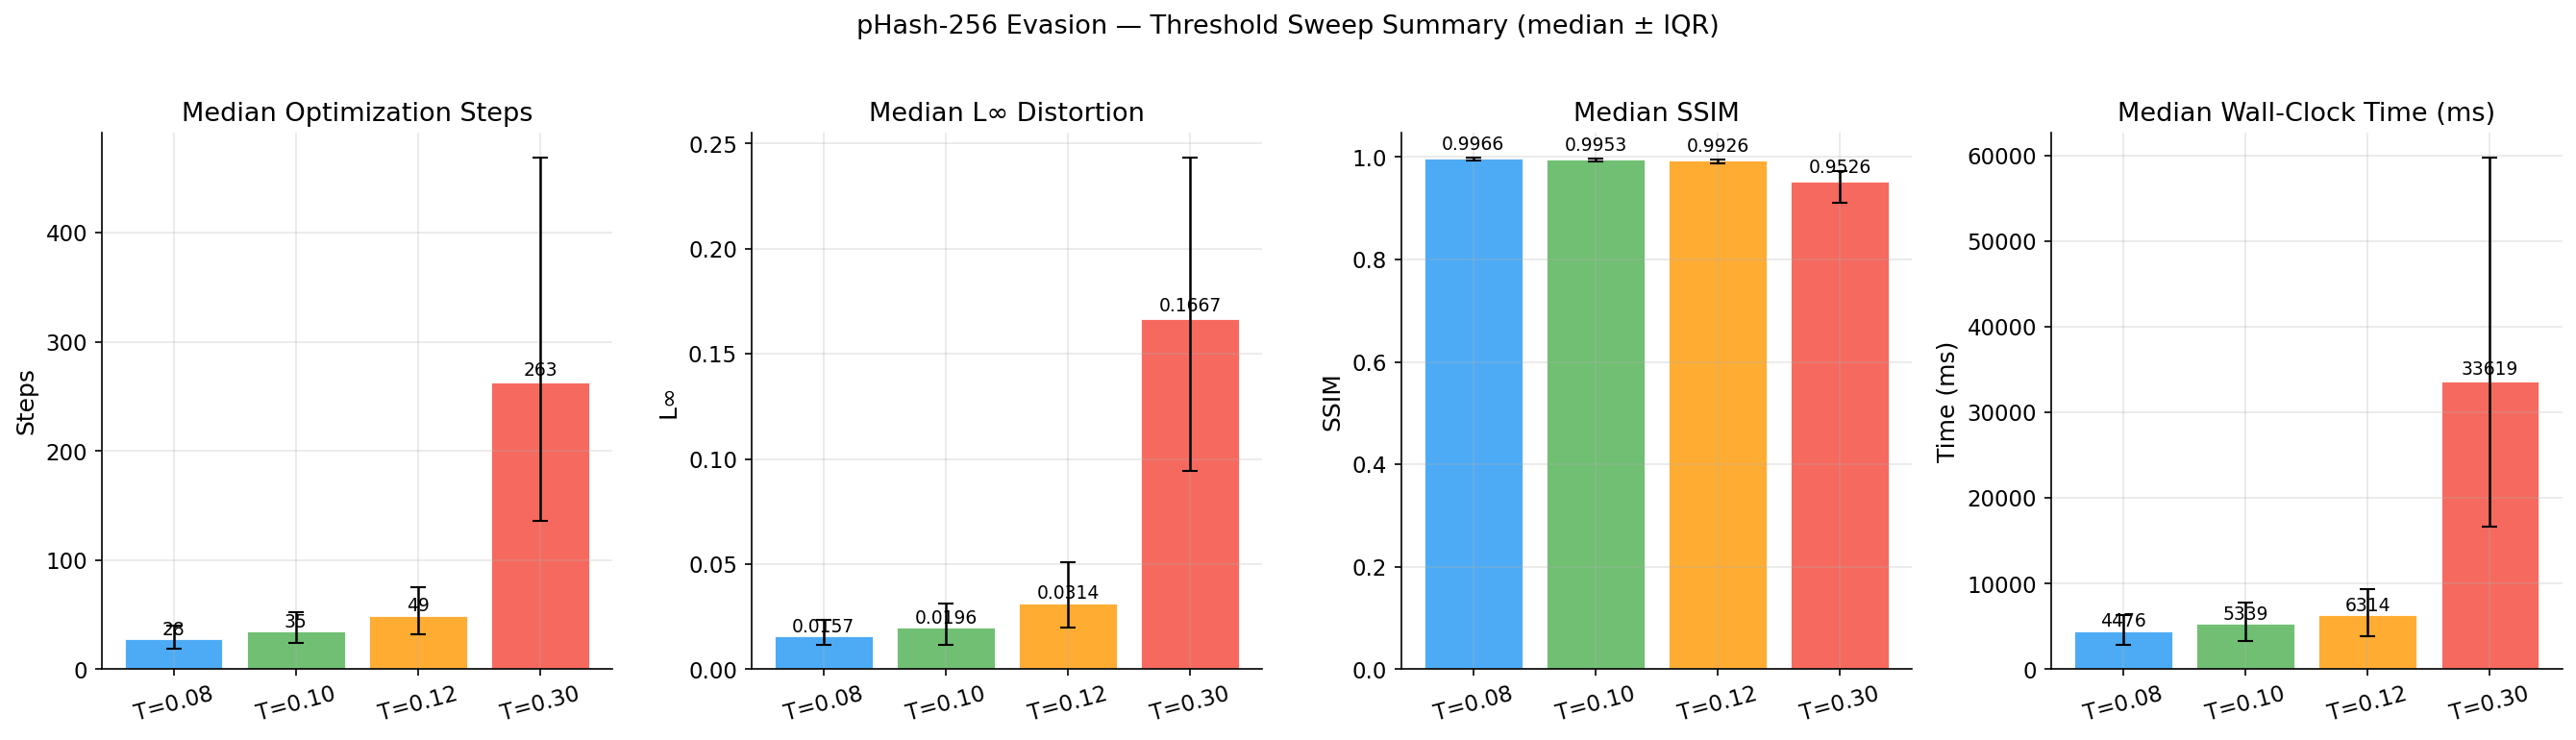

In [7]:
metrics_bar = [
    ('steps',   'Median Optimization Steps', 'Steps'),
    ('l_inf',   'Median L∞ Distortion',      'L∞'),
    ('ssim',    'Median SSIM',                'SSIM'),
    ('time_ms', 'Median Wall-Clock Time (ms)','Time (ms)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (metric, title, ylabel) in zip(axes, metrics_bar):
    medians = [success[t][metric].median() for t in THRESHOLDS]
    p25     = [success[t][metric].quantile(0.25) for t in THRESHOLDS]
    p75     = [success[t][metric].quantile(0.75) for t in THRESHOLDS]
    colors  = [COLORS[k] for k in THRESH_KEYS]

    bars = ax.bar(THRESH_LABELS, medians, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
    # IQR error bars
    ax.errorbar(THRESH_LABELS, medians,
                yerr=[np.array(medians)-np.array(p25), np.array(p75)-np.array(medians)],
                fmt='none', color='black', capsize=4, linewidth=1.2)

    for bar, val in zip(bars, medians):
        fmt = f'{val:.0f}' if metric in ('steps','time_ms') else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt, ha='center', va='bottom', fontsize=9)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('pHash-256 Evasion — Threshold Sweep Summary (median ± IQR)', fontsize=13, y=1.02)
plt.tight_layout()
out = FIGURES_DIR / 'phash256_threshold_sweep_bars.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 7. SSIM Distribution — Violin + Box Plot per Threshold

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_ssim_distributions.png


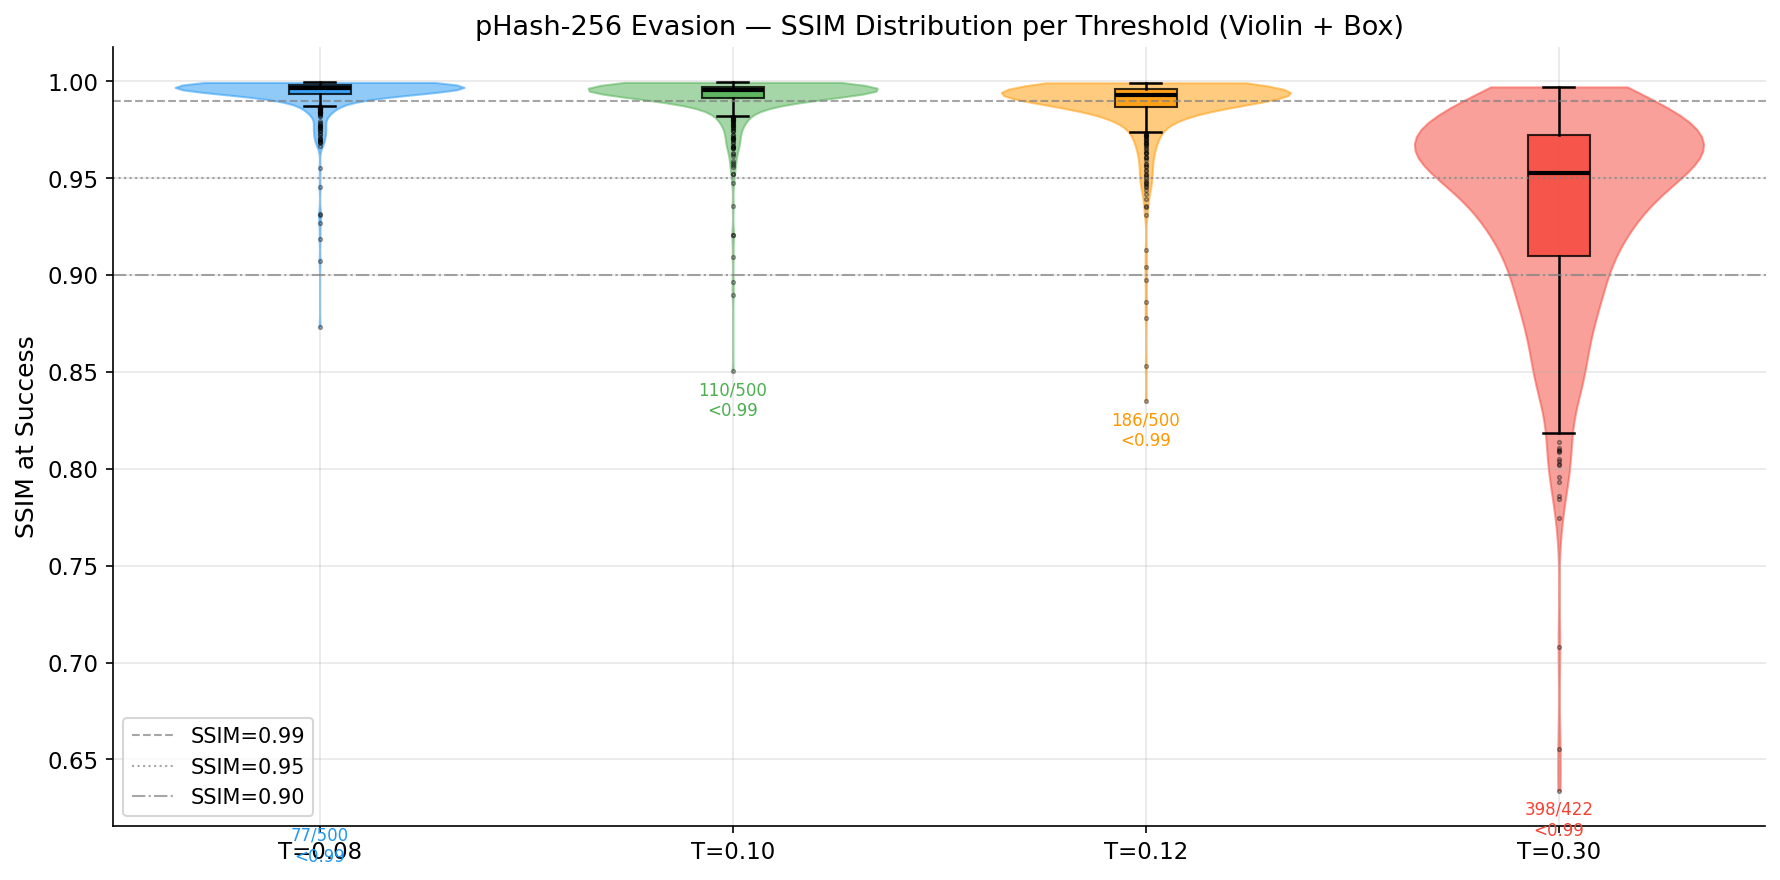

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

data = [success[t]['ssim'].values for t in THRESHOLDS]
colors = [COLORS[k] for k in THRESH_KEYS]

parts = ax.violinplot(data, positions=range(len(THRESHOLDS)),
                      showmedians=False, showextrema=False, widths=0.7)
for i, (pc, color) in enumerate(zip(parts['bodies'], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)
    pc.set_edgecolor(color)

bp = ax.boxplot(data, positions=range(len(THRESHOLDS)),
                widths=0.15, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Reference lines
for thresh_val, ls, lbl in [(0.99, '--', 'SSIM=0.99'), (0.95, ':', 'SSIM=0.95'), (0.90, '-.', 'SSIM=0.90')]:
    ax.axhline(thresh_val, color='grey', linestyle=ls, linewidth=1.0, alpha=0.7, label=lbl)

# Annotate counts below 0.99
for i, t in enumerate(THRESHOLDS):
    n_below = (success[t]['ssim'] < 0.99).sum()
    n_total = len(success[t])
    ax.text(i, ax.get_ylim()[0] if i==0 else success[t]['ssim'].min() - 0.005,
            f'{n_below}/{n_total}\n<0.99', ha='center', va='top', fontsize=8, color=colors[i])

ax.set_xticks(range(len(THRESHOLDS)))
ax.set_xticklabels(THRESH_LABELS)
ax.set_ylabel('SSIM at Success')
ax.set_title('pHash-256 Evasion — SSIM Distribution per Threshold (Violin + Box)')
ax.legend(loc='lower left')

plt.tight_layout()
out = FIGURES_DIR / 'phash256_ssim_distributions.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 8. L∞ Distribution — CDF per Threshold

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_linf_cdf.png


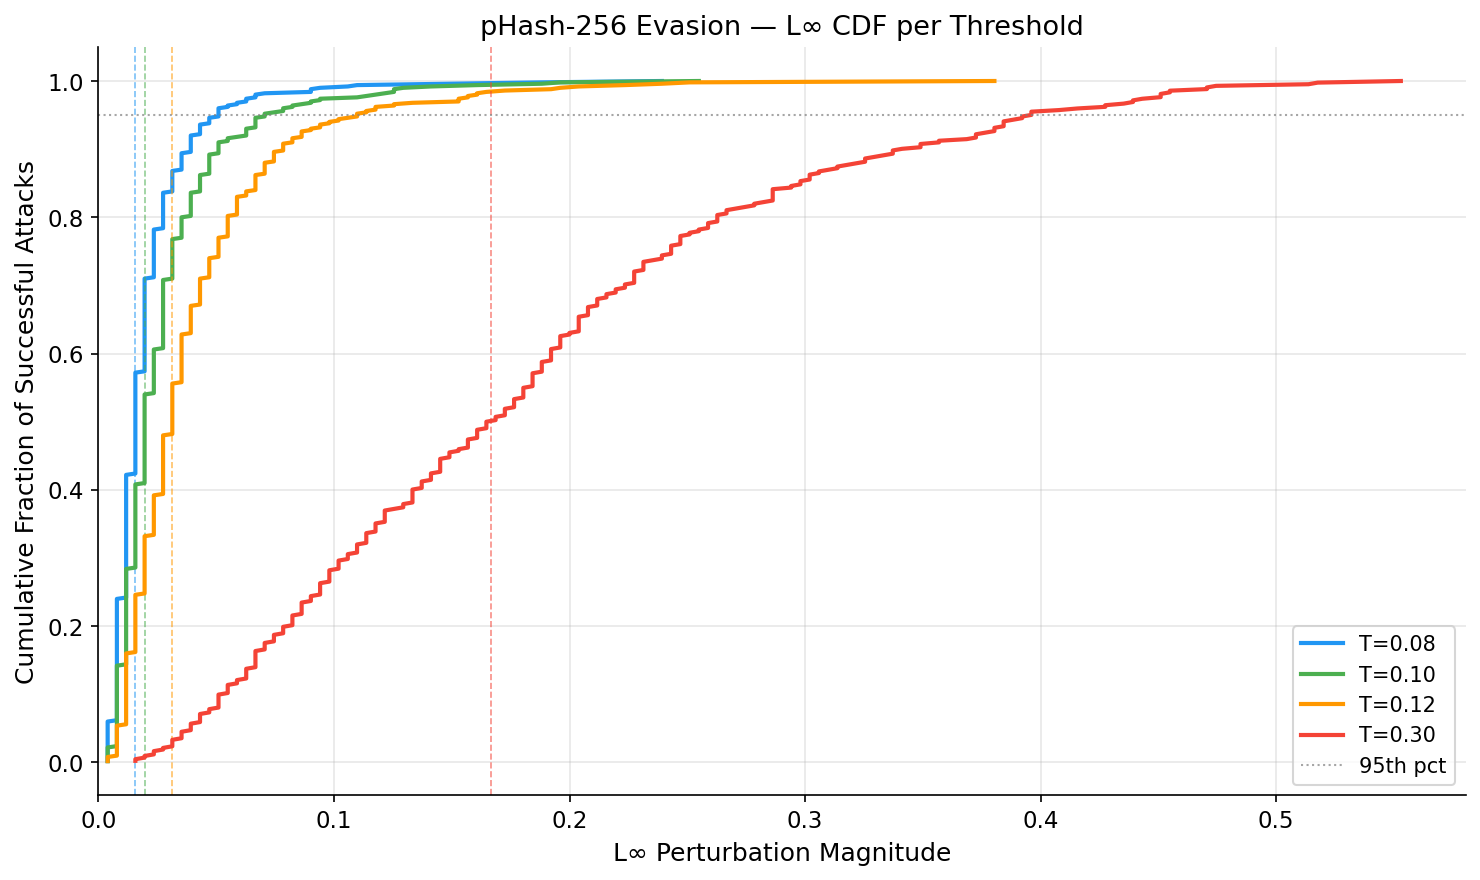

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for t, key, label in zip(THRESHOLDS, THRESH_KEYS, THRESH_LABELS):
    s = np.sort(success[t]['l_inf'].values)
    cdf = np.arange(1, len(s)+1) / len(s)
    ax.plot(s, cdf, color=COLORS[key], linewidth=2.0, label=label)
    med = np.median(s)
    ax.axvline(med, color=COLORS[key], linestyle='--', linewidth=0.8, alpha=0.6)

ax.axhline(0.95, color='grey', linestyle=':', linewidth=1.0, alpha=0.7, label='95th pct')
ax.set_xlabel('L∞ Perturbation Magnitude')
ax.set_ylabel('Cumulative Fraction of Successful Attacks')
ax.set_title('pHash-256 Evasion — L∞ CDF per Threshold')
ax.legend()
ax.set_xlim(left=0)

plt.tight_layout()
out = FIGURES_DIR / 'phash256_linf_cdf.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 9. Quantization Structure — dist_raw Distributions

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_dist_raw_distribution.png


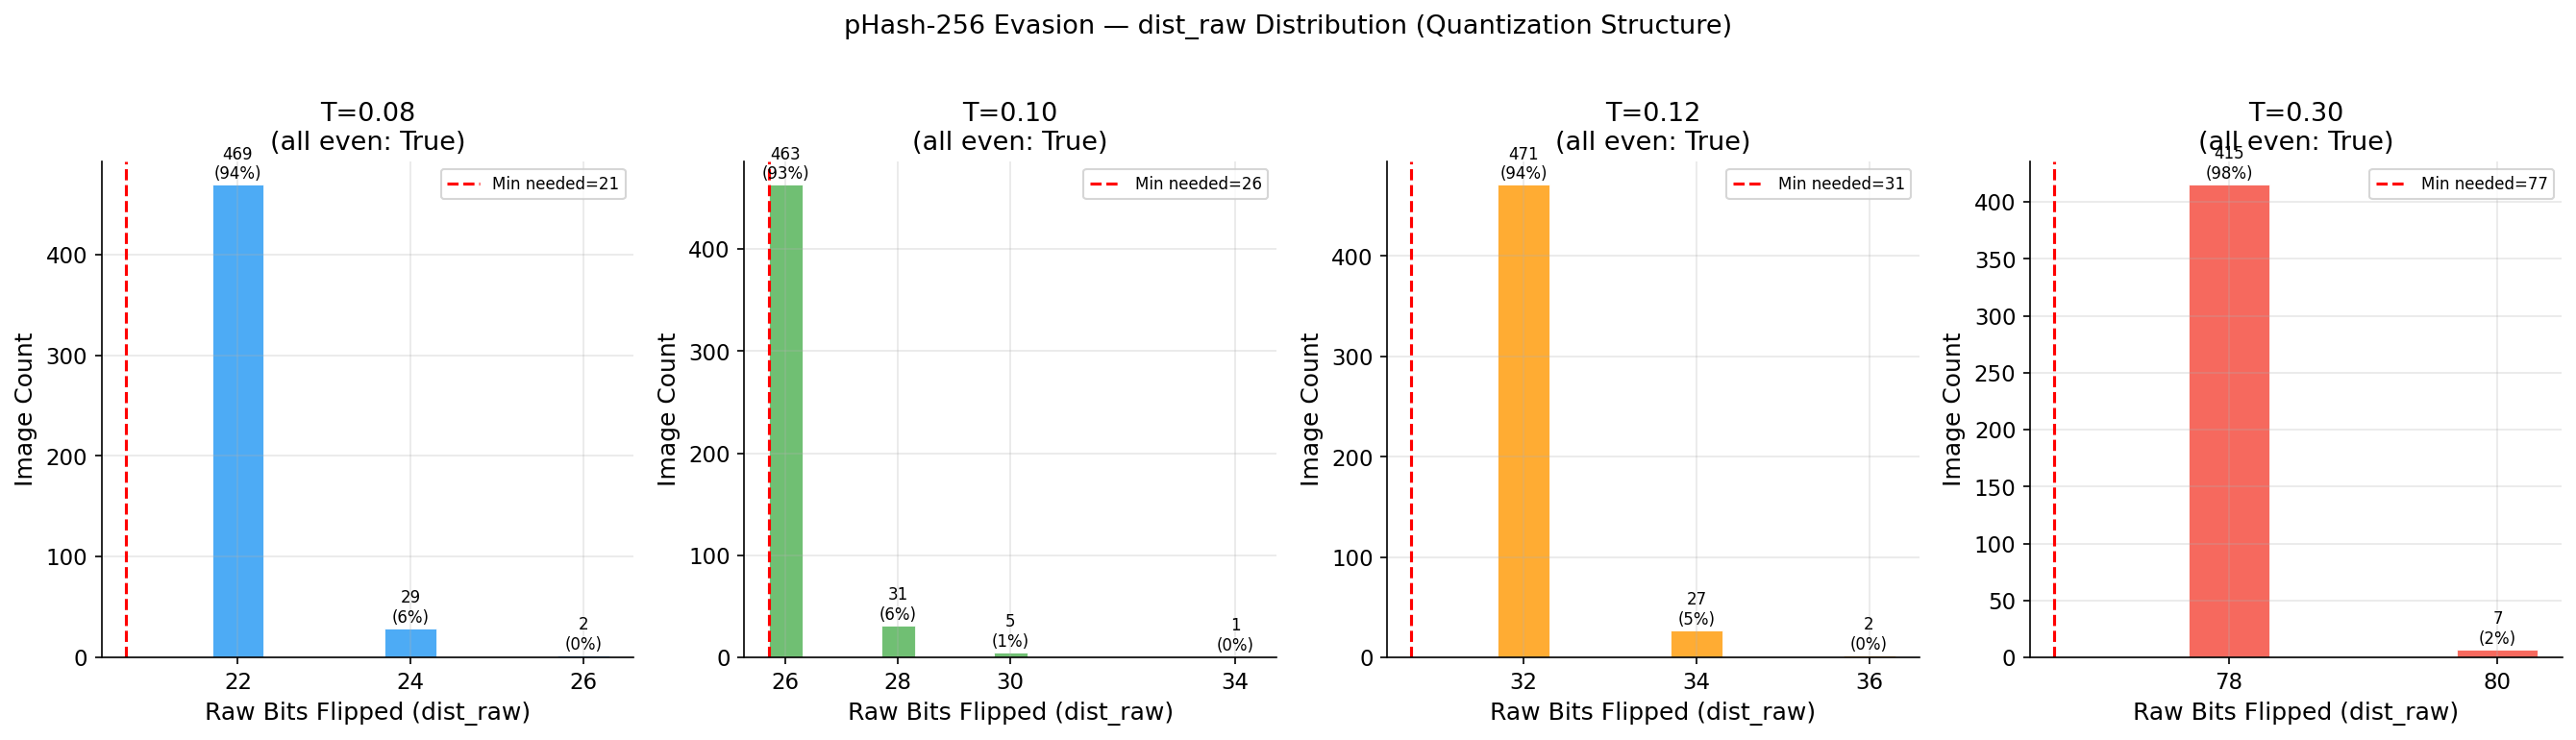


── Quantization structure verification ──
T=0.08: min_needed=21, first_even≥min=22, observed_min=22, pct_even=100.0%
T=0.10: min_needed=26, first_even≥min=26, observed_min=26, pct_even=100.0%
T=0.12: min_needed=31, first_even≥min=32, observed_min=32, pct_even=100.0%
T=0.30: min_needed=77, first_even≥min=78, observed_min=78, pct_even=100.0%


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (t, key, label) in zip(axes, zip(THRESHOLDS, THRESH_KEYS, THRESH_LABELS)):
    dist_raws = success[t]['dist_raw'].values
    counter = Counter(dist_raws.astype(int))
    x_vals = sorted(counter.keys())
    y_vals = [counter[x] for x in x_vals]

    bars = ax.bar(x_vals, y_vals, color=COLORS[key], alpha=0.8,
                  edgecolor='white', linewidth=0.5, width=0.6)

    for bar, x, y in zip(bars, x_vals, y_vals):
        pct = y / len(dist_raws) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{y}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=8)

    min_needed = int(np.ceil(256 * t))
    ax.axvline(min_needed - 0.3, color='red', linestyle='--', linewidth=1.5,
               label=f'Min needed={min_needed}')

    all_even = all(v % 2 == 0 for v in x_vals)
    ax.set_title(f'{label}\n(all even: {all_even})')
    ax.set_xlabel('Raw Bits Flipped (dist_raw)')
    ax.set_ylabel('Image Count')
    ax.legend(fontsize=8)
    ax.set_xticks(x_vals)

fig.suptitle('pHash-256 Evasion — dist_raw Distribution (Quantization Structure)', fontsize=13, y=1.02)
plt.tight_layout()
out = FIGURES_DIR / 'phash256_dist_raw_distribution.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

# Confirm T=0.10 != T=0.12
print('\n── Quantization structure verification ──')
for t, key, label in zip(THRESHOLDS, THRESH_KEYS, THRESH_LABELS):
    raws = success[t]['dist_raw'].astype(int)
    min_needed = int(np.ceil(256 * t))
    first_even = min_needed if min_needed % 2 == 0 else min_needed + 1
    pct_even = (raws % 2 == 0).mean() * 100
    print(f'{label}: min_needed={min_needed}, first_even≥min={first_even}, '
          f'observed_min={raws.min()}, pct_even={pct_even:.1f}%')

## 10. T=0.30 Failure Analysis

T=0.30 failures: 78 / 500
All at step cap (2000): True

Failure dist_norm summary:
count    78.0000
mean      0.2495
std       0.0413
min       0.1406
25%       0.2266
50%       0.2539
75%       0.2812
max       0.2969
Name: dist_norm, dtype: float64
Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_t030_failure_analysis.png


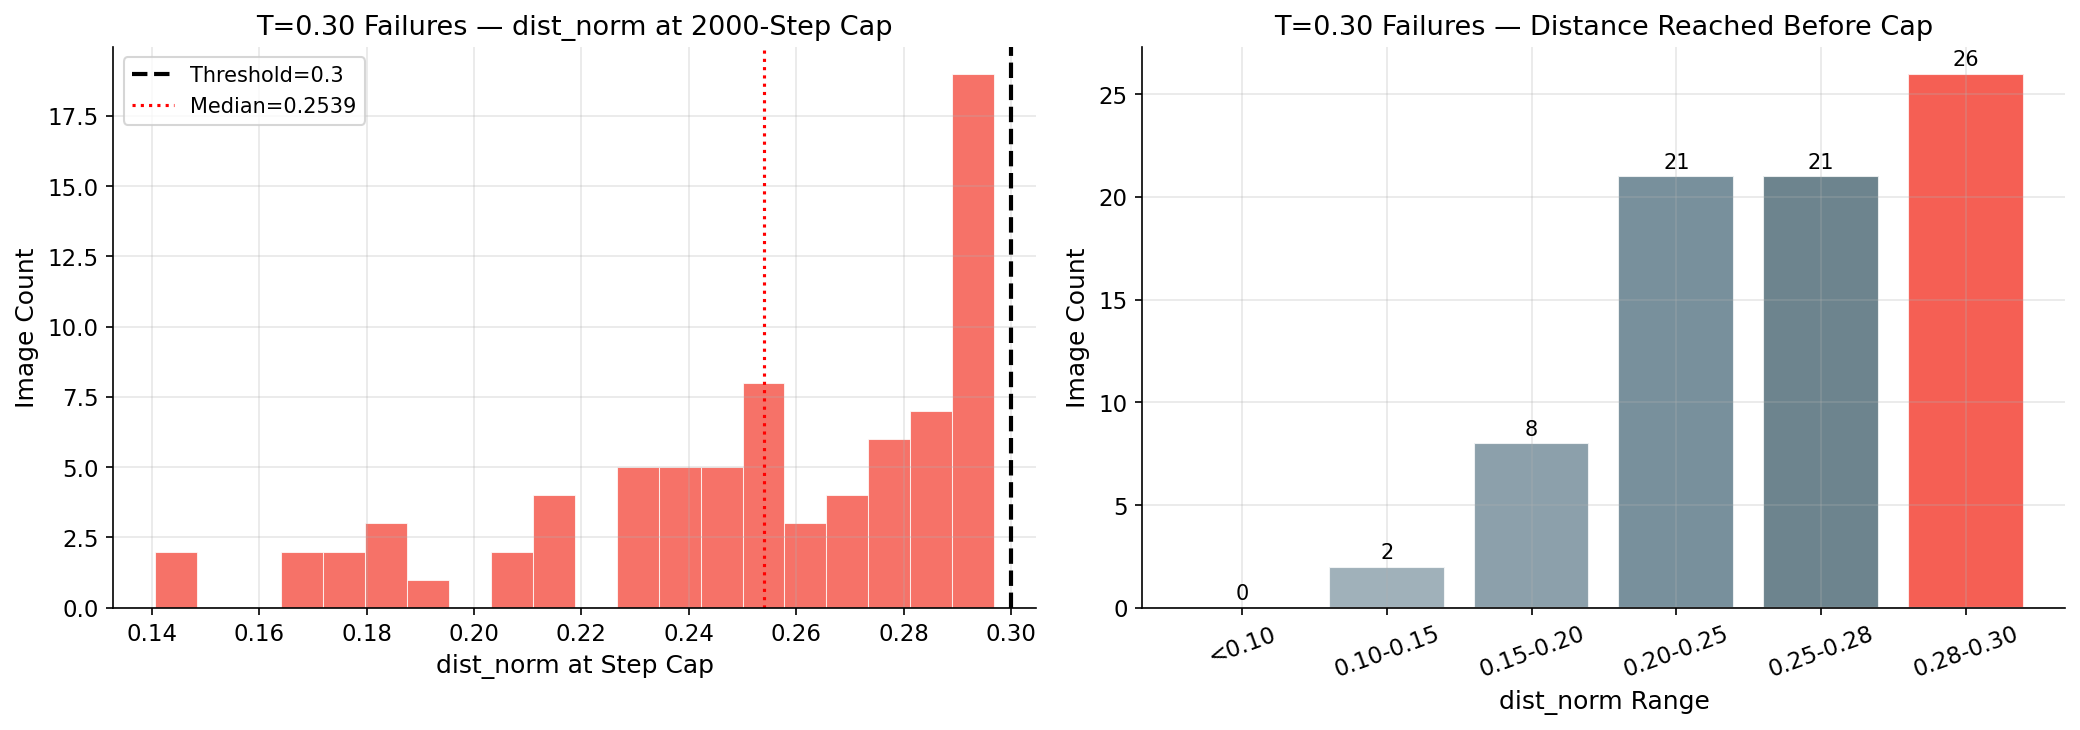


── Success vs Failure distortion at T=0.30 ──
Successes SSIM: count    422.0000
mean       0.9346
std        0.0536
min        0.6338
25%        0.9098
50%        0.9526
75%        0.9721
max        0.9971
Name: ssim, dtype: float64
Failures  dist_norm: count    78.0000
mean      0.2495
std       0.0413
min       0.1406
25%       0.2266
50%       0.2539
75%       0.2812
max       0.2969
Name: dist_norm, dtype: float64


In [11]:
t030 = 0.30
df_fail = failure[t030].copy()

print(f'T=0.30 failures: {len(df_fail)} / {len(dfs[t030])}')
print(f'All at step cap (2000): {(df_fail["steps"] == 2000).all()}')
print(f'\nFailure dist_norm summary:')
print(df_fail['dist_norm'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of failure dist_norm
ax = axes[0]
ax.hist(df_fail['dist_norm'], bins=20, color=COLORS['T030'], alpha=0.75,
        edgecolor='white', linewidth=0.5)
ax.axvline(t030, color='black', linestyle='--', linewidth=2, label=f'Threshold={t030}')
ax.axvline(df_fail['dist_norm'].median(), color='red', linestyle=':',
           linewidth=1.5, label=f'Median={df_fail["dist_norm"].median():.4f}')
ax.set_xlabel('dist_norm at Step Cap')
ax.set_ylabel('Image Count')
ax.set_title('T=0.30 Failures — dist_norm at 2000-Step Cap')
ax.legend()

# Binned distribution of failure dist_norm
ax = axes[1]
bins = [0.0, 0.10, 0.15, 0.20, 0.25, 0.28, 0.30]
bin_labels = ['<0.10','0.10-0.15','0.15-0.20','0.20-0.25','0.25-0.28','0.28-0.30']
counts = []
for lo, hi in zip(bins[:-1], bins[1:]):
    counts.append(((df_fail['dist_norm'] >= lo) & (df_fail['dist_norm'] < hi)).sum())

colors_bins = ['#B0BEC5','#90A4AE','#78909C','#607D8B','#546E7A','#F44336']
bars = ax.bar(bin_labels, counts, color=colors_bins, alpha=0.85, edgecolor='white')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(c), ha='center', va='bottom', fontsize=10)
ax.set_xlabel('dist_norm Range')
ax.set_ylabel('Image Count')
ax.set_title('T=0.30 Failures — Distance Reached Before Cap')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
out = FIGURES_DIR / 'phash256_t030_failure_analysis.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

# Compare success vs failure distortion at T=0.30
print('\n── Success vs Failure distortion at T=0.30 ──')
print('Successes SSIM:', success[t030]['ssim'].describe().round(4))
print('Failures  dist_norm:', df_fail['dist_norm'].describe().round(4))

## 11. SSIM Threshold Breakdown — Stacked Bar

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_ssim_quality_breakdown.png


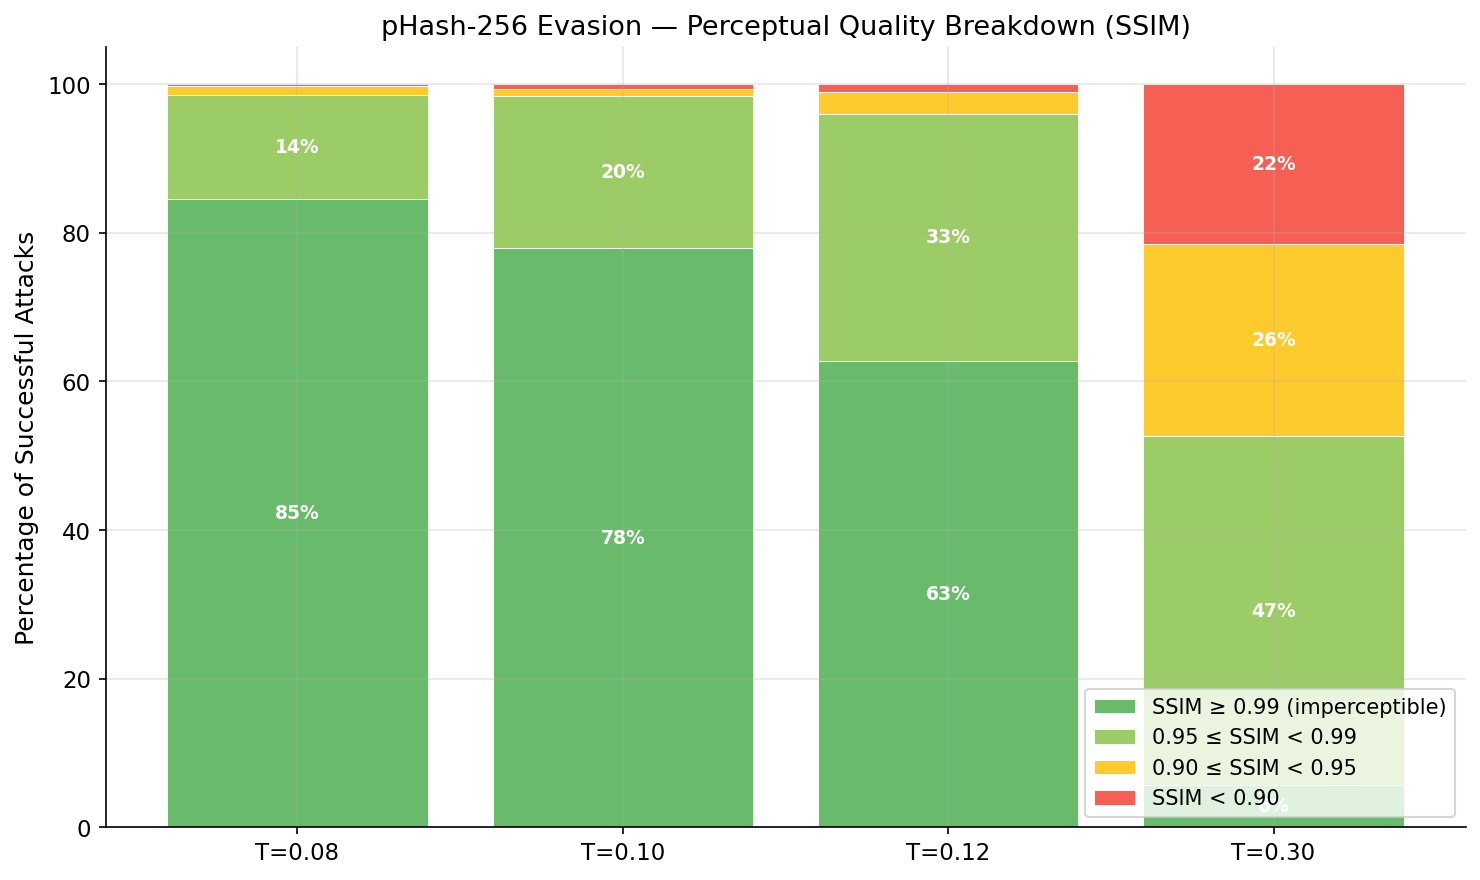

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ssim_thresholds = [0.99, 0.95, 0.90]
labels_ssim = ['SSIM ≥ 0.99 (imperceptible)', '0.95 ≤ SSIM < 0.99', '0.90 ≤ SSIM < 0.95', 'SSIM < 0.90']
palette = ['#4CAF50', '#8BC34A', '#FFC107', '#F44336']

bottoms = np.zeros(len(THRESHOLDS))
band_data = []

for t in THRESHOLDS:
    s = success[t]['ssim']
    n = len(s)
    n_99  = (s >= 0.99).sum() / n * 100
    n_95  = ((s >= 0.95) & (s < 0.99)).sum() / n * 100
    n_90  = ((s >= 0.90) & (s < 0.95)).sum() / n * 100
    n_bad = (s < 0.90).sum() / n * 100
    band_data.append([n_99, n_95, n_90, n_bad])

band_data = np.array(band_data).T  # shape (4, n_thresholds)
bottoms = np.zeros(len(THRESHOLDS))

for band_vals, color, label in zip(band_data, palette, labels_ssim):
    bars = ax.bar(THRESH_LABELS, band_vals, bottom=bottoms,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.5, label=label)
    for bar, val in zip(bars, band_vals):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += band_vals

ax.set_ylabel('Percentage of Successful Attacks')
ax.set_title('pHash-256 Evasion — Perceptual Quality Breakdown (SSIM)')
ax.set_ylim(0, 105)
ax.legend(loc='lower right')

plt.tight_layout()
out = FIGURES_DIR / 'phash256_ssim_quality_breakdown.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 12. Steps vs SSIM Scatter — Attack Cost vs Perceptual Quality

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_steps_vs_ssim_scatter.png


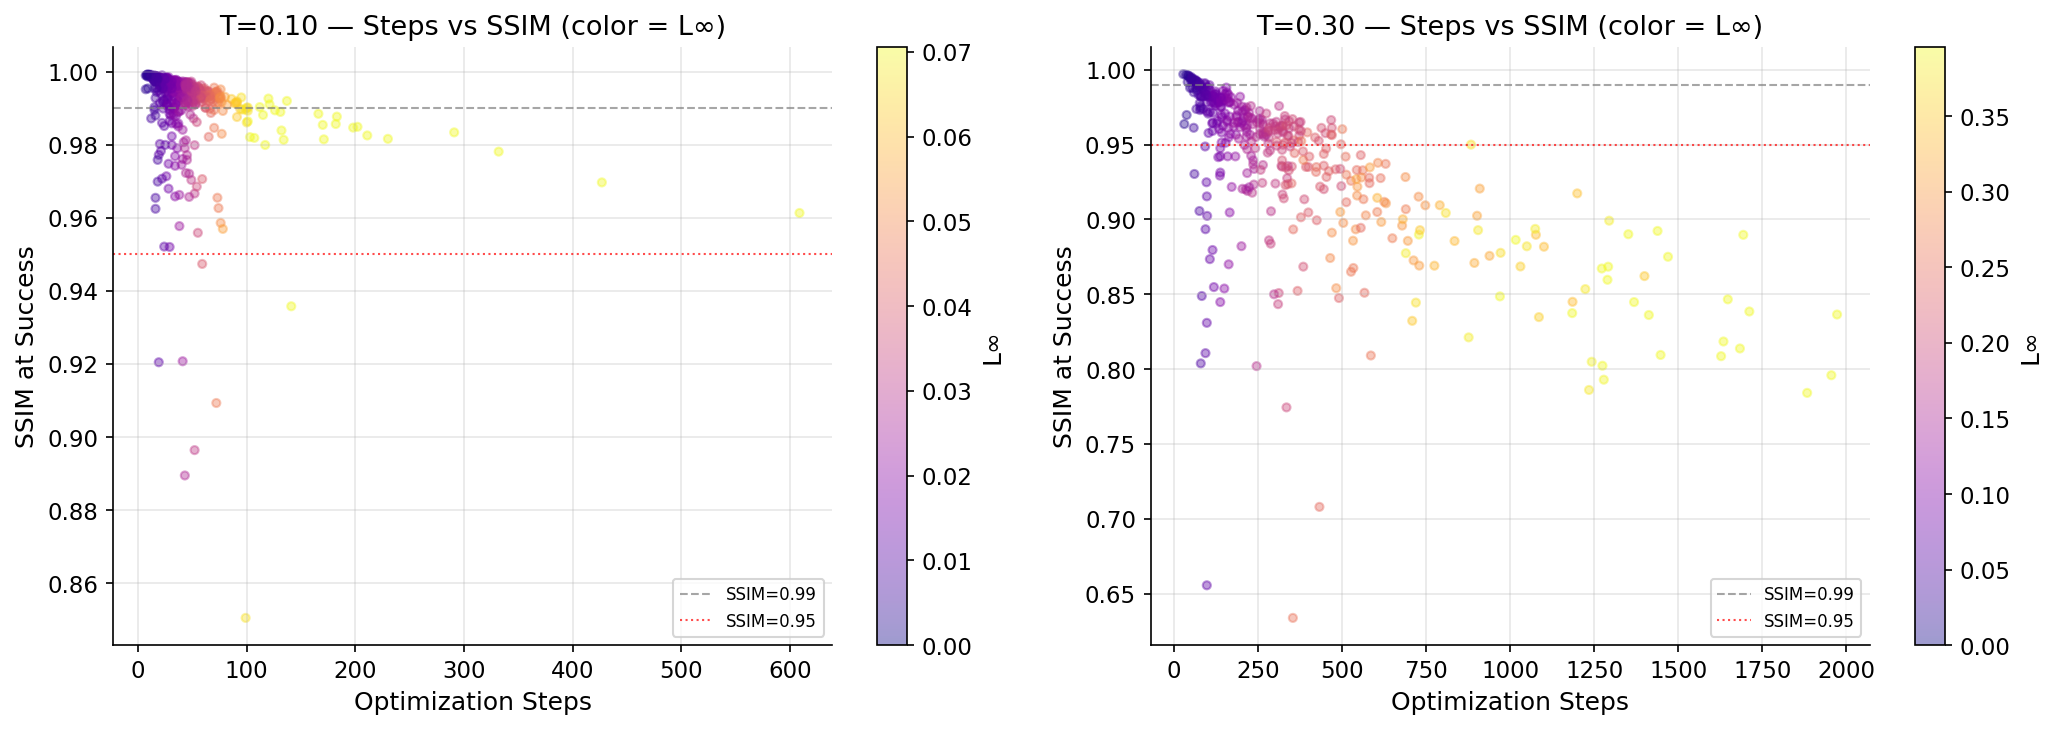

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, t_main, t_stress in [(axes[0], 0.10, None), (axes[1], 0.30, None)]:
    t = t_main
    s = success[t]
    key = THRESH_KEYS[THRESHOLDS.index(t)]
    label = THRESH_LABELS[THRESHOLDS.index(t)]
    sc = ax.scatter(s['steps'], s['ssim'], c=s['l_inf'],
                    cmap='plasma', alpha=0.4, s=15,
                    vmin=0, vmax=s['l_inf'].quantile(0.95))
    plt.colorbar(sc, ax=ax, label='L∞')
    ax.axhline(0.99, color='grey', linestyle='--', linewidth=1.0, alpha=0.7, label='SSIM=0.99')
    ax.axhline(0.95, color='red',  linestyle=':',  linewidth=1.0, alpha=0.7, label='SSIM=0.95')
    ax.set_xlabel('Optimization Steps')
    ax.set_ylabel('SSIM at Success')
    ax.set_title(f'{label} — Steps vs SSIM (color = L∞)')
    ax.legend(fontsize=8)

plt.tight_layout()
out = FIGURES_DIR / 'phash256_steps_vs_ssim_scatter.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 13. Cross-Algorithm Comparison at T=0.10

In [14]:
# Ground truth from prior phase findings docs
# pHash-64: Phase 2 results  |  PDQ: PDQ findings  |  NeuralHash: Phase 1 results
ALGO_DATA = {
    'pHash-64': {
        'bits': 64, 'arch': 'DCT classical',
        'steps_median': 13, 'steps_mean': 19.3, 'steps_p95': 40,
        'l_inf_median': 0.0078, 'ssim_median': 0.9991, 'time_ms_median': 1194,
        'success_rate': 1.0,
    },
    'PDQ': {
        'bits': 256, 'arch': 'DCT enhanced',
        'steps_median': 31, 'steps_mean': 29.3, 'steps_p95': 46,
        'l_inf_median': 0.0353, 'ssim_median': 0.9837, 'time_ms_median': 1266,
        'success_rate': 1.0,
    },
    'NeuralHash': {
        'bits': 96, 'arch': 'Neural MobileNet',
        'steps_median': 37, 'steps_mean': 46.5, 'steps_p95': 112,
        'l_inf_median': 0.0196, 'ssim_median': 0.9987, 'time_ms_median': 5878,
        'success_rate': 1.0,
    },
}

# Add pHash-256 from actual data
s010 = success[0.10]
ALGO_DATA['pHash-256'] = {
    'bits': 256, 'arch': 'DCT extended (ours)',
    'steps_median':  s010['steps'].median(),
    'steps_mean':    s010['steps'].mean(),
    'steps_p95':     s010['steps'].quantile(0.95),
    'l_inf_median':  s010['l_inf'].median(),
    'ssim_median':   s010['ssim'].median(),
    'time_ms_median':s010['time_ms'].median(),
    'success_rate':  1.0,
}

algo_df = pd.DataFrame(ALGO_DATA).T.reset_index().rename(columns={'index':'algorithm'})
algo_order = ['pHash-64', 'PDQ', 'pHash-256', 'NeuralHash']
algo_df = algo_df.set_index('algorithm').loc[algo_order].reset_index()

out_table = TABLES_DIR / 'four_algo_comparison_T010.csv'
algo_df.to_csv(out_table, index=False, float_format='%.4f')
print(f'Saved: {out_table}')
print(algo_df[['algorithm','bits','arch','steps_median','l_inf_median','ssim_median','time_ms_median']].to_string(index=False))

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/tables/four_algo_comparison_T010.csv
 algorithm bits                arch steps_median l_inf_median ssim_median time_ms_median
  pHash-64   64       DCT classical           13       0.0078      0.9991           1194
       PDQ  256        DCT enhanced           31       0.0353      0.9837           1266
 pHash-256  256 DCT extended (ours)         35.0     0.019608    0.995304    5338.563125
NeuralHash   96    Neural MobileNet           37       0.0196      0.9987           5878


Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/four_algo_comparison_T010.png


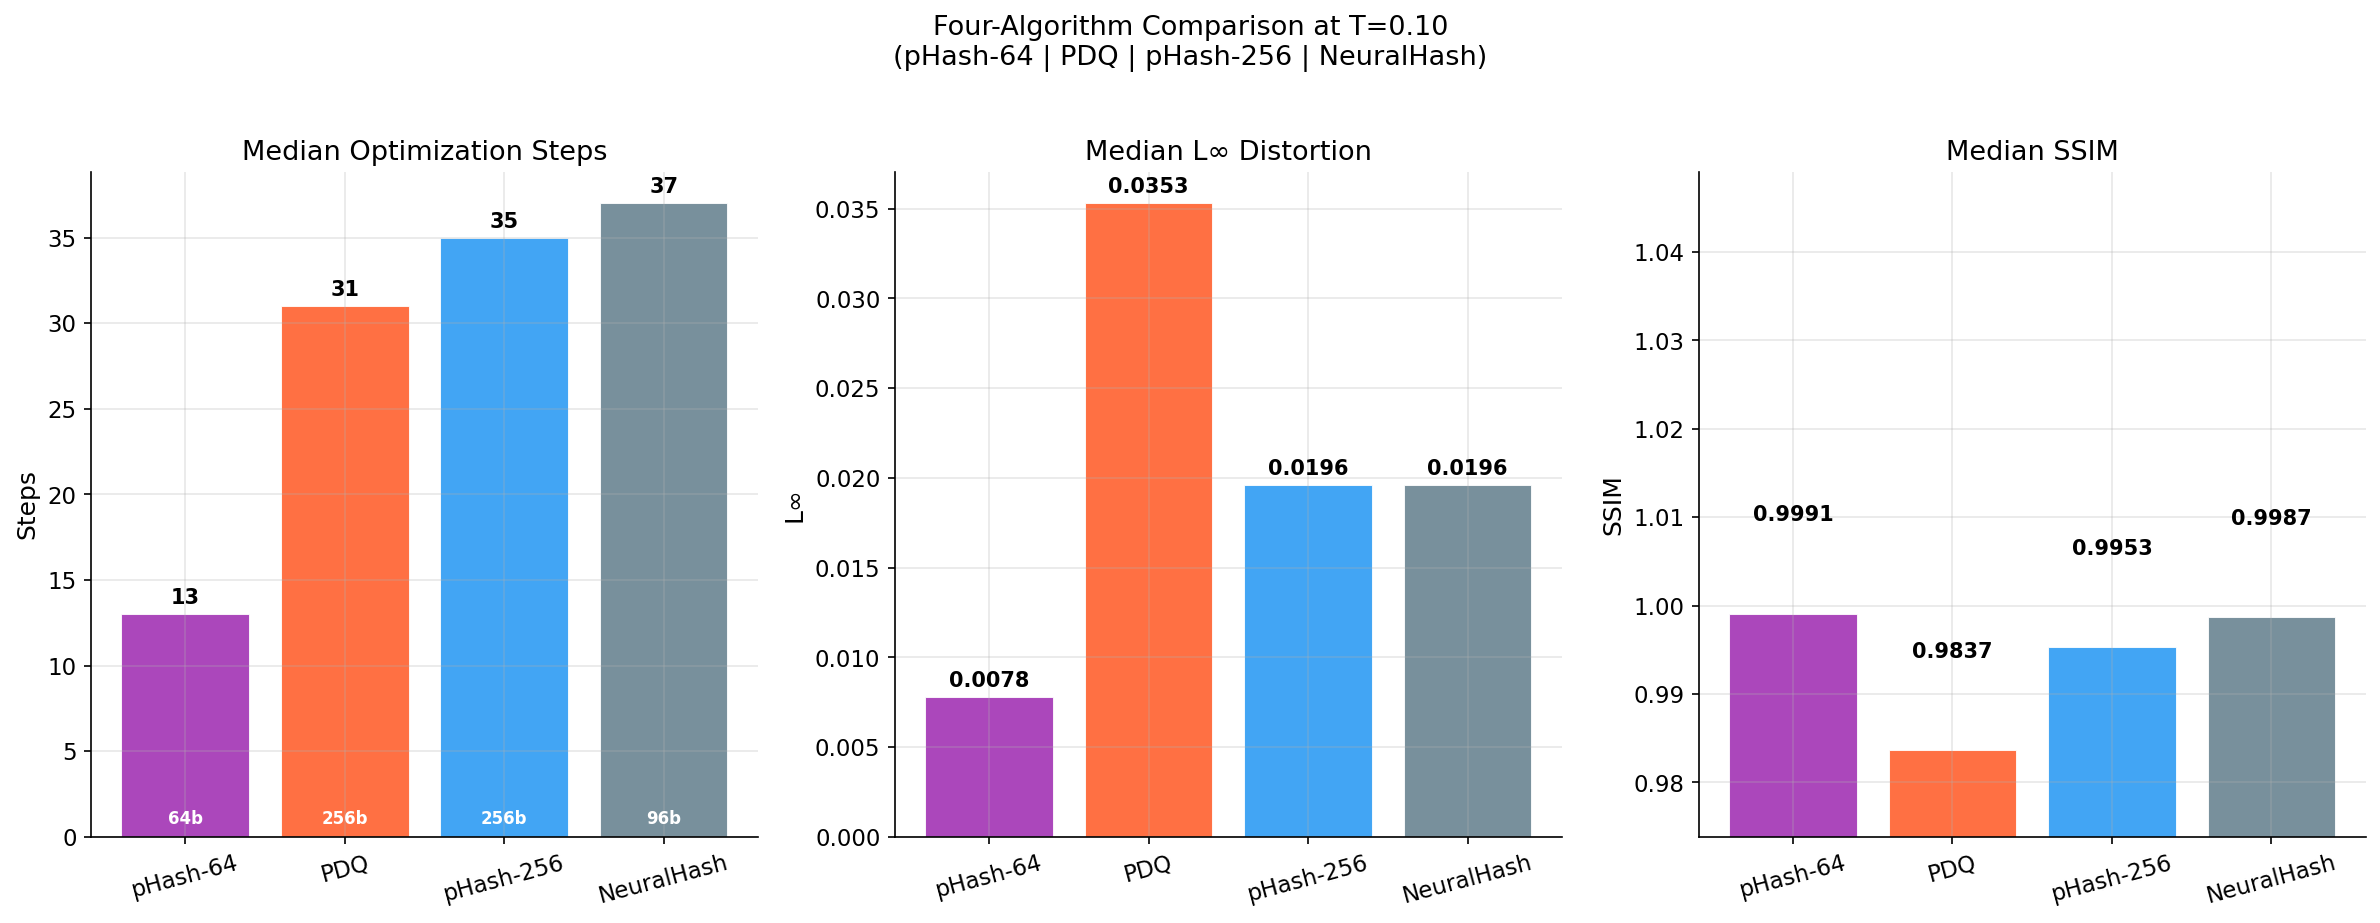

In [15]:
# ── Multi-panel cross-algorithm bar chart ──────────────────────────────────
algo_colors = [COLORS['phash64'], COLORS['pdq'], COLORS['phash256'], COLORS['neuralhash']]
algos = algo_df['algorithm'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

panels = [
    ('steps_median',   'Median Optimization Steps', 'Steps',    False),
    ('l_inf_median',   'Median L∞ Distortion',      'L∞',       False),
    ('ssim_median',    'Median SSIM',                'SSIM',     True),
]

for ax, (col, title, ylabel, invert) in zip(axes, panels):
    vals = algo_df[col].astype(float).tolist()
    bars = ax.bar(algos, vals, color=algo_colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.0f}' if col == 'steps_median' else f'{val:.4f}'
        ypos = bar.get_height() + (max(vals)*0.01)
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                fmt, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)
    if invert:
        ax.set_ylim(bottom=min(vals)*0.99)

# Add bit-count annotations on steps panel
for i, (algo, bits) in enumerate(zip(algos, algo_df['bits'].astype(int))):
    axes[0].text(i, 0.5, f'{bits}b', ha='center', va='bottom',
                 fontsize=8, color='white', fontweight='bold')

fig.suptitle('Four-Algorithm Comparison at T=0.10\n(pHash-64 | PDQ | pHash-256 | NeuralHash)',
             fontsize=13, y=1.02)
plt.tight_layout()
out = FIGURES_DIR / 'four_algo_comparison_T010.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 14. pHash-64 vs pHash-256 — Direct Head-to-Head (Steps CDF Overlay)

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/figures/phash256_vs_phash64_comparison.png


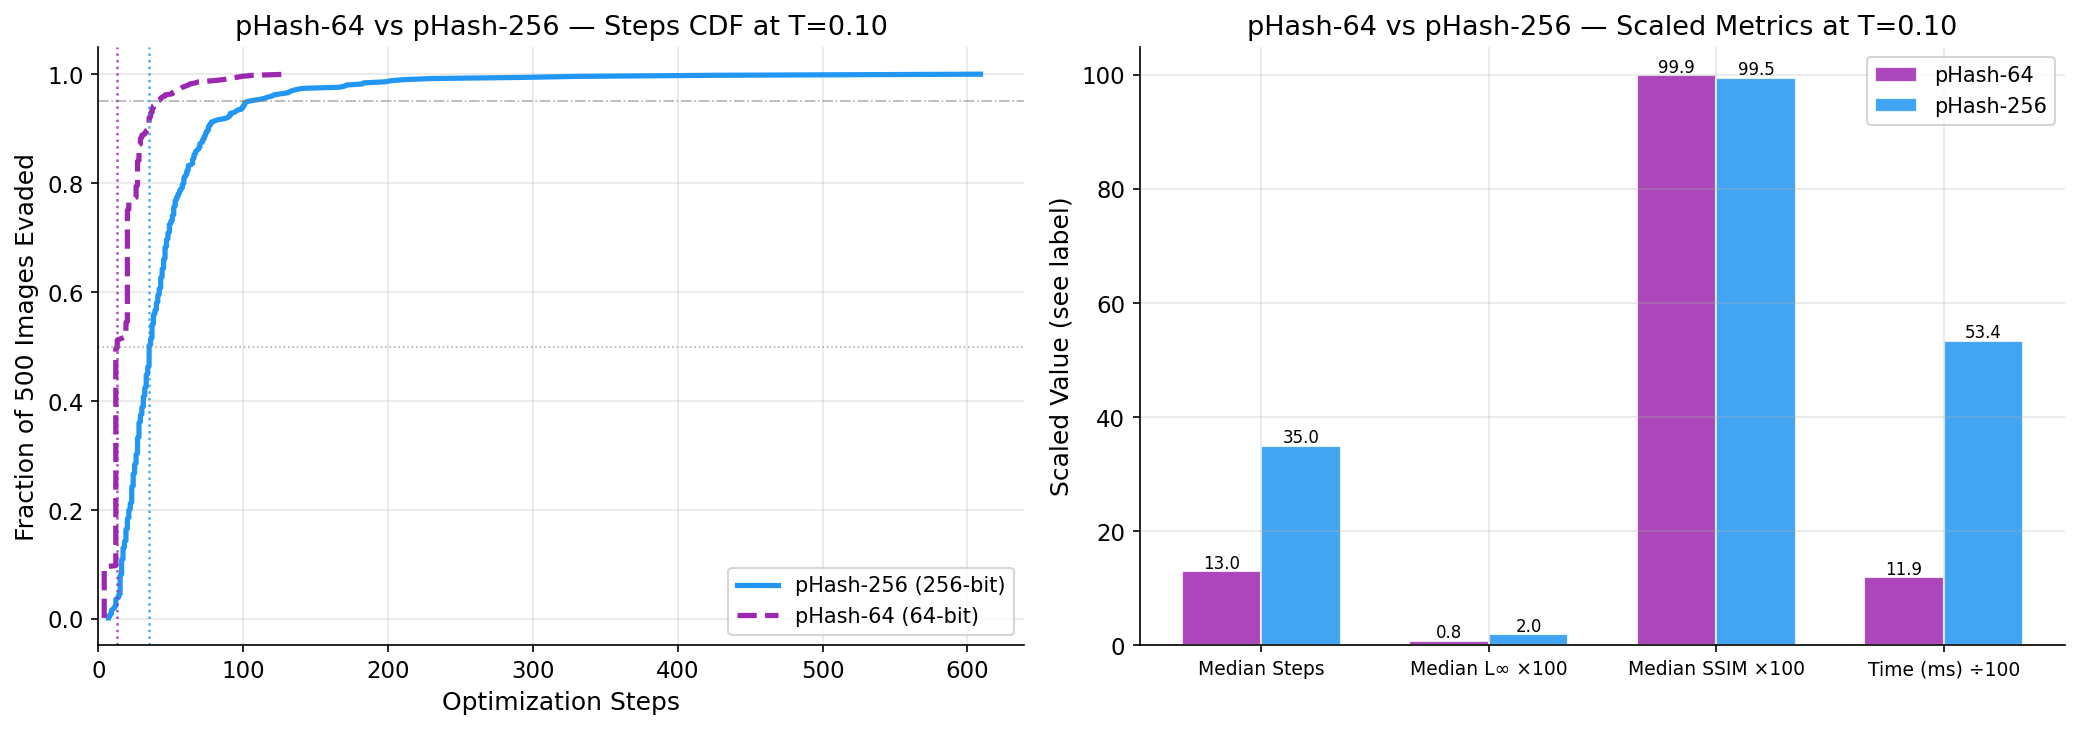

In [16]:
# pHash-64 step data from Phase 2 logs — adjust path as needed
phash64_log = LOGS_DIR / 'attack_steps_phash_evasion_mt500_T0.10.csv'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── CDF comparison ──
ax = axes[0]
s256 = np.sort(success[0.10]['steps'].values)
cdf256 = np.arange(1, len(s256)+1) / 500
ax.plot(s256, cdf256, color=COLORS['phash256'], linewidth=2.5, label='pHash-256 (256-bit)')

if phash64_log.exists():
    df64 = pd.read_csv(phash64_log)
    # Phase-2 pHash-64 logs use step/linf naming while this notebook uses steps/l_inf.
    step_col = 'steps' if 'steps' in df64.columns else 'step'
    linf_col = 'l_inf' if 'l_inf' in df64.columns else 'linf'

    s64 = np.sort(df64[df64['success'] == 1][step_col].values)
    cdf64 = np.arange(1, len(s64)+1) / 500
    ax.plot(s64, cdf64, color=COLORS['phash64'], linewidth=2.5,
            linestyle='--', label='pHash-64 (64-bit)')
    ax.axvline(np.median(s64), color=COLORS['phash64'], linestyle=':', linewidth=1.2, alpha=0.8)

    ph64_steps_median = float(df64[df64['success'] == 1][step_col].median())
    ph64_linf_median = float(df64[df64['success'] == 1][linf_col].median())
else:
    ax.annotate('pHash-64 log not found\n(add to logs/ dir)', xy=(0.5, 0.5),
                xycoords='axes fraction', ha='center')
    ph64_steps_median = 13.0
    ph64_linf_median = 0.0078

ax.axvline(np.median(s256), color=COLORS['phash256'], linestyle=':', linewidth=1.2, alpha=0.8)
ax.axhline(0.50, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(0.95, color='grey', linestyle='-.', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Optimization Steps')
ax.set_ylabel('Fraction of 500 Images Evaded')
ax.set_title('pHash-64 vs pHash-256 — Steps CDF at T=0.10')
ax.legend()
ax.set_xlim(left=0)

# ── Metric comparison bar ──
ax = axes[1]
compare_metrics = ['Median Steps', 'Median L∞ ×100', 'Median SSIM ×100', 'Time (ms) ÷100']
ph64_vals = [ph64_steps_median, ph64_linf_median * 100, 0.9991 * 100, 1194 / 100]
ph256_vals = [float(s010['steps'].median()),
              float(s010['l_inf'].median()) * 100,
              float(s010['ssim'].median()) * 100,
              float(s010['time_ms'].median()) / 100]

x = np.arange(len(compare_metrics))
width = 0.35
ax.bar(x - width/2, ph64_vals, width, color=COLORS['phash64'], alpha=0.85,
       label='pHash-64', edgecolor='white')
ax.bar(x + width/2, ph256_vals, width, color=COLORS['phash256'], alpha=0.85,
       label='pHash-256', edgecolor='white')

for xi, (v64, v256) in enumerate(zip(ph64_vals, ph256_vals)):
    ax.text(xi - width/2, v64 + 0.5, f'{v64:.1f}', ha='center', fontsize=8)
    ax.text(xi + width/2, v256 + 0.5, f'{v256:.1f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(compare_metrics, fontsize=9)
ax.set_title('pHash-64 vs pHash-256 — Scaled Metrics at T=0.10')
ax.set_ylabel('Scaled Value (see label)')
ax.legend()

plt.tight_layout()
out = FIGURES_DIR / 'phash256_vs_phash64_comparison.png'
plt.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## 15. All-Threshold Summary Table — Export

In [17]:
summary_rows = []
for t in THRESHOLDS:
    s = success[t]
    f = failure[t]
    n_total = len(dfs[t])
    row = {
        'threshold': t,
        'n_total': n_total,
        'n_success': len(s),
        'n_failure': len(f),
        'success_rate_pct': round(len(s)/n_total*100, 1),
        'steps_median': s['steps'].median(),
        'steps_mean':   s['steps'].mean().round(1),
        'steps_p25':    s['steps'].quantile(0.25),
        'steps_p75':    s['steps'].quantile(0.75),
        'steps_p95':    s['steps'].quantile(0.95),
        'steps_max':    s['steps'].max(),
        'steps_skew':   round(float(stats.skew(s['steps'])), 3),
        'l_inf_median': round(s['l_inf'].median(), 4),
        'l_inf_p95':    round(s['l_inf'].quantile(0.95), 4),
        'l2_median':    round(s['l2'].median(), 4),
        'ssim_median':  round(s['ssim'].median(), 4),
        'ssim_lt_099':  (s['ssim'] < 0.99).sum(),
        'ssim_lt_095':  (s['ssim'] < 0.95).sum(),
        'ssim_lt_090':  (s['ssim'] < 0.90).sum(),
        'time_ms_median': round(s['time_ms'].median(), 0),
        'time_ms_p95':    round(s['time_ms'].quantile(0.95), 0),
        'dist_raw_median': s['dist_raw'].median(),
        'dist_raw_min':    s['dist_raw'].min(),
        'dist_raw_max':    s['dist_raw'].max(),
        'pct_even_dist_raw': round((s['dist_raw'].astype(int) % 2 == 0).mean()*100, 1),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_path = TABLES_DIR / 'phash256_threshold_sweep.csv'
summary_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print()
print(summary_df[['threshold','n_success','success_rate_pct',
                   'steps_median','steps_mean','steps_p95',
                   'l_inf_median','ssim_median','time_ms_median']].to_string(index=False))

Saved: /home/exouser/ar-sec-eval/fdeph_eval/analysis/tables/phash256_threshold_sweep.csv

 threshold  n_success  success_rate_pct  steps_median  steps_mean  steps_p95  l_inf_median  ssim_median  time_ms_median
      0.08        500             100.0          28.0        35.0      76.00        0.0157       0.9966          4476.0
      0.10        500             100.0          35.0        46.3     103.20        0.0196       0.9953          5339.0
      0.12        500             100.0          49.0        67.6     159.35        0.0314       0.9926          6314.0
      0.30        422              84.4         263.0       378.1    1270.50        0.1667       0.9526         33619.0


## 16. Digest

In [18]:
print('=' * 65)
print('  pHash-256 EVASION — ANALYSIS DIGEST')
print('=' * 65)
print()
print('SUCCESS RATES')
print('  T=0.08/0.10/0.12: 500/500 (100%) — no failures')
print('  T=0.30:           422/500 (84.4%) — 78 cap-limited failures')
print()
print('STEP DISTRIBUTIONS (right-skewed at all thresholds)')
for t in THRESHOLDS:
    s = success[t]['steps']
    print(f'  T={t:.2f}: median={s.median():.0f}, mean={s.mean():.1f}, '
          f'P95={s.quantile(.95):.0f}, skew={stats.skew(s):.2f}')
print()
print('PERCEPTUAL DISTORTION at T=0.10')
s010 = success[0.10]
print(f'  Median L∞:  {s010["l_inf"].median():.4f}')
print(f'  Median SSIM:{s010["ssim"].median():.4f}')
print(f'  SSIM<0.99:  {(s010["ssim"]<0.99).sum()}/500')
print(f'  SSIM<0.95:  {(s010["ssim"]<0.95).sum()}/500')
print()
print('QUANTIZATION STRUCTURE')
print('  All dist_raw values are even integers (100% at all thresholds)')
print('  T=0.10 ≠ T=0.12 (26 vs 32 bit targets) — NO identity artifact')
print()
print('FOUR-ALGORITHM COMPARISON at T=0.10')
print(f'  pHash-64:   13 steps, L∞=0.0078, SSIM=0.9991, t=1194ms')
print(f'  PDQ:        31 steps, L∞=0.0353, SSIM=0.9837, t=1266ms')
print(f'  pHash-256:  {s010["steps"].median():.0f} steps, '
      f'L∞={s010["l_inf"].median():.4f}, '
      f'SSIM={s010["ssim"].median():.4f}, '
      f't={s010["time_ms"].median():.0f}ms')
print(f'  NeuralHash: 37 steps, L∞=0.0196, SSIM=0.9987, t=5878ms')
print()
print('KEY FINDINGS')
print('  1. 4× more bits (64→256) costs 2.7× more steps — sub-linear scaling')
print('  2. pHash-256 vs PDQ at T=0.10: 35 vs 31 steps — Jarosz+DC = ~4 steps')
print('  3. pHash-256 L∞ = NeuralHash L∞ = 0.0196 at T=0.10 (coincidence)')
print('  4. DCT architecture is the dominant vulnerability, not bit count')
print('  5. T=0.30 failures are optimization dead-ends (max dist_norm=0.2969)')
print()
print('All figures saved to:', FIGURES_DIR)
print('All tables saved to: ', TABLES_DIR)

  pHash-256 EVASION — ANALYSIS DIGEST

SUCCESS RATES
  T=0.08/0.10/0.12: 500/500 (100%) — no failures
  T=0.30:           422/500 (84.4%) — 78 cap-limited failures

STEP DISTRIBUTIONS (right-skewed at all thresholds)
  T=0.08: median=28, mean=35.0, P95=76, skew=6.72
  T=0.10: median=35, mean=46.3, P95=103, skew=6.01
  T=0.12: median=49, mean=67.6, P95=159, skew=8.10
  T=0.30: median=263, mean=378.1, P95=1270, skew=1.99

PERCEPTUAL DISTORTION at T=0.10
  Median L∞:  0.0196
  Median SSIM:0.9953
  SSIM<0.99:  110/500
  SSIM<0.95:  8/500

QUANTIZATION STRUCTURE
  All dist_raw values are even integers (100% at all thresholds)
  T=0.10 ≠ T=0.12 (26 vs 32 bit targets) — NO identity artifact

FOUR-ALGORITHM COMPARISON at T=0.10
  pHash-64:   13 steps, L∞=0.0078, SSIM=0.9991, t=1194ms
  PDQ:        31 steps, L∞=0.0353, SSIM=0.9837, t=1266ms
  pHash-256:  35 steps, L∞=0.0196, SSIM=0.9953, t=5339ms
  NeuralHash: 37 steps, L∞=0.0196, SSIM=0.9987, t=5878ms

KEY FINDINGS
  1. 4× more bits (64→256) c